SPLIT
Train: 140 patients | 19381 cells
Val  : 20 patients | 2940 cells
Test : 40 patients | 5237 cells
Train classes: Counter({0: 9732, 1: 9649})
Val classes  : Counter({0: 1571, 1: 1369})
Test classes : Counter({1: 2761, 0: 2476})

STEP 1: Load pretrained ResNet18+TTA
Baseline (unpruned) results on test set:
  Accuracy  : 97.90%
  F1        : 0.9801
  AUC       : 0.9966
  TTA time  : 14.55 ms/img (2.91 ms/img/aug)

STEP 2: Apply 30% global magnitude pruning
Global sparsity: 30.00%
Zeroed weights : 3,350,381 / 11,167,936

STEP 3: Fine-tune pruned model (5 epochs)


Epoch 1: Train Loss: 0.2423 | Val Acc: 98.67%


Epoch 2: Train Loss: 0.2412 | Val Acc: 98.81%


Epoch 3: Train Loss: 0.2415 | Val Acc: 98.54%


Epoch 4: Train Loss: 0.2424 | Val Acc: 98.81%


Epoch 5: Train Loss: 0.2411 | Val Acc: 98.81%
Best validation accuracy: 98.81%

STEP 4: Final evaluation on test set
  Accuracy  : 98.11%
  F1        : 0.9821
  AUC       : 0.9972
  TTA time  : 10.65 ms/img (2.13 ms/img/aug)

PRUNING SUMMARY (Patient-Level Split)
Model                           Acc%      F1     AUC   Total (ms)  Per aug (ms)
------------------------------------------------------------------------------------------
ResNet18+TTA (unpruned)        97.90  0.9801  0.9966        14.55          2.91
ResNet18+TTA (30% pruned)      98.11  0.9821  0.9972        10.65          2.13

Accuracy change: +0.21 pp
F1 change      : +0.0020
AUC change     : +0.0006

Saved: pruning_comparison.pdf / .png (300 DPI)


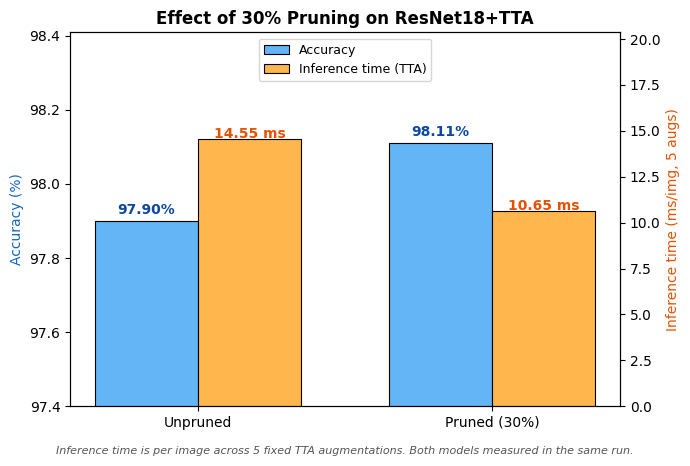

Saved: ablation_3_TTA_pruned30.pth


In [1]:
import os
import cv2
import copy
import time
import random
import warnings
import re
from collections import defaultdict, Counter

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.utils.prune as prune
from torch.utils.data import DataLoader, Dataset
import torchvision.models as models
import torchvision.transforms as transforms
from torchvision.transforms import RandomErasing
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score
)
from tqdm import tqdm
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

# ============================================================
# REPRODUCIBILITY
# ============================================================
def set_deterministic(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    np.random.seed(seed)
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

set_deterministic(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ============================================================
# DATASET
# ============================================================
class OriginalDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None, target_size=(256, 256)):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform
        self.target_size = target_size

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = cv2.imread(self.image_paths[idx])
        if img is None:
            img = np.zeros((*self.target_size, 3), dtype=np.uint8)
        else:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, self.target_size, interpolation=cv2.INTER_AREA)
        img = Image.fromarray(img)
        label = self.labels[idx]
        if self.transform:
            img = self.transform(img)
        return img, torch.tensor(label, dtype=torch.long)

# ============================================================
# MODEL
# ============================================================
def create_resnet18_tta(num_classes=2):
    model = models.resnet18(pretrained=False)
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)
    return model.to(device)

# ============================================================
# FIXED TTA TRANSFORMS
# Each TTA transform uses a fixed seed so the same
# augmentation is applied to the same image every run.
# ============================================================
def get_tta_transforms():
    return [
        # 0: identity
        transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225])
        ]),
        # 1: horizontal flip (deterministic)
        transforms.Compose([
            transforms.RandomHorizontalFlip(p=1.0),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225])
        ]),
        # 2: vertical flip (deterministic)
        transforms.Compose([
            transforms.RandomVerticalFlip(p=1.0),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225])
        ]),
        # 3: both flips (deterministic)
        transforms.Compose([
            transforms.RandomHorizontalFlip(p=1.0),
            transforms.RandomVerticalFlip(p=1.0),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225])
        ]),
        # 4: fixed 15-degree rotation
        transforms.Compose([
            transforms.RandomRotation(degrees=(15, 15)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225])
        ]),
    ]

# ============================================================
# TTA INFERENCE
# ============================================================
def evaluate_with_tta(model, test_paths, test_labels, device):
    tta_transforms = get_tta_transforms()

    model.eval()
    all_preds, all_targets, all_probs = [], [], []

    start_time = time.perf_counter()
    with torch.no_grad():
        for aug_idx, tf in enumerate(tta_transforms):
            aug_ds = OriginalDataset(test_paths, test_labels, transform=tf)
            aug_loader = DataLoader(aug_ds, batch_size=64, shuffle=False,
                                    num_workers=4, pin_memory=True)
            probs_this_aug = []
            targets_this_aug = []
            for inputs, targets in aug_loader:
                inputs = inputs.to(device)
                outputs = model(inputs)
                probs = torch.softmax(outputs, dim=1)
                probs_this_aug.append(probs.cpu())
                targets_this_aug.append(targets)
            probs_this_aug = torch.cat(probs_this_aug, dim=0)
            targets_this_aug = torch.cat(targets_this_aug, dim=0)

            if aug_idx == 0:
                avg_probs = probs_this_aug
                all_targets = targets_this_aug.numpy()
            else:
                avg_probs = avg_probs + probs_this_aug

    avg_probs = avg_probs / len(tta_transforms)
    preds = torch.argmax(avg_probs, dim=1).numpy()
    probs_pos = avg_probs[:, 1].numpy()

    end_time = time.perf_counter()
    total_time = end_time - start_time
    n_images = len(test_paths)
    per_image_time = total_time / n_images * 1000          # total ms/img
    per_aug_time = total_time / (n_images * len(tta_transforms)) * 1000

    return {
        'accuracy'  : accuracy_score(all_targets, preds),
        'precision' : precision_score(all_targets, preds,
                                      average='binary', pos_label=1),
        'recall'    : recall_score(all_targets, preds,
                                   average='binary', pos_label=1),
        'f1'        : f1_score(all_targets, preds,
                               average='binary', pos_label=1),
        'auc'       : roc_auc_score(all_targets, probs_pos),
        'total_time_ms_per_img': per_image_time,
        'per_aug_time_ms': per_aug_time,
        'predictions': preds,
        'targets': all_targets,
    }

def evaluate_standard(model, loader, device):
    model.eval()
    all_preds, all_targets, all_probs = [], [], []
    start_time = time.perf_counter()
    with torch.no_grad():
        for inputs, targets in loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())
            all_probs.extend(probs[:, 1].cpu().numpy())
    end_time = time.perf_counter()
    total_time = end_time - start_time
    n_images = len(loader.dataset)

    return {
        'accuracy'  : accuracy_score(all_targets, all_preds),
        'f1'        : f1_score(all_targets, all_preds,
                               average='binary', pos_label=1),
        'auc'       : roc_auc_score(all_targets, all_probs),
        'inference_time_ms': total_time / n_images * 1000,
    }

# ============================================================
# PATIENT-LEVEL SPLIT
# ============================================================
base_path = '/kaggle/input/datasets/iarunava/cell-images-for-detecting-malaria/cell_images'
categories = ['Parasitized', 'Uninfected']

image_paths, labels = [], []
for cat_idx, cat in enumerate(categories):
    folder = os.path.join(base_path, cat)
    exts = ('.png', '.jpg', '.jpeg')
    files = sorted([os.path.join(folder, f)
                    for f in os.listdir(folder)
                    if f.lower().endswith(exts)])
    image_paths.extend(files)
    labels.extend([cat_idx] * len(files))

path_to_label = dict(zip(image_paths, labels))

def get_patient_id(path):
    match = re.search(r'P(\d+)', os.path.basename(path))
    if match:
        return f"P{match.group(1)}"
    return os.path.basename(path).split('_')[0]

patient_to_images = defaultdict(list)
patient_to_labels = defaultdict(list)
for path, label in zip(image_paths, labels):
    pid = get_patient_id(path)
    patient_to_images[pid].append(path)
    patient_to_labels[pid].append(label)

unique_patients = sorted(patient_to_images.keys())

patient_majority = {}
for pid in unique_patients:
    labs = patient_to_labels[pid]
    counts = Counter(labs)
    max_count = max(counts.values())
    candidates = [c for c, n in counts.items() if n == max_count]
    patient_majority[pid] = min(candidates)

patient_labels = [patient_majority[p] for p in unique_patients]

# Split into train / val / test
# 160 train patients → 140 train + 20 val
train_p, temp_p = train_test_split(
    unique_patients, test_size=0.20, random_state=42, stratify=patient_labels
)
train_p, val_p = train_test_split(
    train_p, test_size=0.125, random_state=42,
    stratify=[patient_majority[p] for p in train_p]
)

train_patient_set = set(train_p)
val_patient_set   = set(val_p)
test_patient_set  = set(temp_p)

train_paths  = [p for pid in train_patient_set for p in patient_to_images[pid]]
train_labels = [path_to_label[p] for p in train_paths]
val_paths    = [p for pid in val_patient_set   for p in patient_to_images[pid]]
val_labels   = [path_to_label[p] for p in val_paths]
test_paths   = [p for pid in test_patient_set  for p in patient_to_images[pid]]
test_labels  = [path_to_label[p] for p in test_paths]

print("=" * 70)
print("SPLIT")
print("=" * 70)
print(f"Train: {len(train_patient_set)} patients | {len(train_paths)} cells")
print(f"Val  : {len(val_patient_set)} patients | {len(val_paths)} cells")
print(f"Test : {len(test_patient_set)} patients | {len(test_paths)} cells")
print(f"Train classes: {Counter(train_labels)}")
print(f"Val classes  : {Counter(val_labels)}")
print(f"Test classes : {Counter(test_labels)}")
print("=" * 70)

# ============================================================
# DATALOADERS
# ============================================================
target_size = (256, 256)

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=90),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
    RandomErasing(p=0.2, scale=(0.02, 0.1))
])

val_test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

train_ds = OriginalDataset(train_paths, train_labels,
                           transform=train_transform,
                           target_size=target_size)
val_ds   = OriginalDataset(val_paths, val_labels,
                           transform=val_test_transform,
                           target_size=target_size)
test_ds  = OriginalDataset(test_paths, test_labels,
                           transform=val_test_transform,
                           target_size=target_size)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True,
                          num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=64, shuffle=False,
                          num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=64, shuffle=False,
                          num_workers=4, pin_memory=True)

# ============================================================
# STEP 1: Load pretrained ResNet18+TTA
# ============================================================
print("\n" + "=" * 70)
print("STEP 1: Load pretrained ResNet18+TTA")
print("=" * 70)

PRETRAINED_PATH = '/kaggle/input/notebooks/sumn2u/ablation-malaria-detection/ablation_3_+_TTA.pth'

model = create_resnet18_tta(num_classes=2)
model.load_state_dict(torch.load(PRETRAINED_PATH, map_location=device))
model = model.to(device)

print("Baseline (unpruned) results on test set:")
baseline_tta = evaluate_with_tta(model, test_paths, test_labels, device)
print(f"  Accuracy  : {baseline_tta['accuracy']*100:.2f}%")
print(f"  F1        : {baseline_tta['f1']:.4f}")
print(f"  AUC       : {baseline_tta['auc']:.4f}")
print(f"  TTA time  : {baseline_tta['total_time_ms_per_img']:.2f} ms/img "
      f"({baseline_tta['per_aug_time_ms']:.2f} ms/img/aug)")

# ============================================================
# STEP 2: Apply 30% global magnitude pruning
# ============================================================
print("\n" + "=" * 70)
print("STEP 2: Apply 30% global magnitude pruning")
print("=" * 70)

parameters_to_prune = []
for name, module in model.named_modules():
    if isinstance(module, (nn.Conv2d, nn.Linear)):
        parameters_to_prune.append((module, 'weight'))

prune.global_unstructured(
    parameters_to_prune,
    pruning_method=prune.L1Unstructured,
    amount=0.30,
)

total_zeros = sum((m.weight == 0).sum().item() for m, _ in parameters_to_prune)
total_weights = sum(m.weight.numel() for m, _ in parameters_to_prune)
print(f"Global sparsity: {total_zeros/total_weights*100:.2f}%")
print(f"Zeroed weights : {total_zeros:,} / {total_weights:,}")

# ============================================================
# STEP 3: Fine-tune pruned model (checkpoint selection on VAL)
# ============================================================
print("\n" + "=" * 70)
print("STEP 3: Fine-tune pruned model (5 epochs)")
print("=" * 70)

for param in model.parameters():
    param.requires_grad = True

optimizer = optim.AdamW(model.parameters(), lr=1e-5, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=5, T_mult=2
)

epochs_finetune = 5
best_val_acc = 0.0
best_state = None

for epoch in range(1, epochs_finetune + 1):
    model.train()
    running_loss = 0.0
    for inputs, targets in tqdm(train_loader,
                                desc=f"Fine-tune Epoch {epoch}/{epochs_finetune}",
                                leave=False):
        inputs = inputs.to(device)
        targets = targets.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        scheduler.step()

        running_loss += loss.item() * inputs.size(0)

    # Validate on val_loader (NOT test_loader)
    model.eval()
    val_preds, val_targets = [], []
    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            _, p = torch.max(outputs, 1)
            val_preds.extend(p.cpu().numpy())
            val_targets.extend(targets.cpu().numpy())

    val_acc = accuracy_score(val_targets, val_preds)
    print(f"Epoch {epoch}: Train Loss: "
          f"{running_loss/len(train_loader.dataset):.4f} | "
          f"Val Acc: {val_acc*100:.2f}%")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state = copy.deepcopy(model.state_dict())

model.load_state_dict(best_state)
print(f"Best validation accuracy: {best_val_acc*100:.2f}%")

# ============================================================
# STEP 4: Remove pruning masks and evaluate once on test set
# ============================================================
print("\n" + "=" * 70)
print("STEP 4: Final evaluation on test set")
print("=" * 70)

for module, name in parameters_to_prune:
    prune.remove(module, name)

pruned_tta = evaluate_with_tta(model, test_paths, test_labels, device)
print(f"  Accuracy  : {pruned_tta['accuracy']*100:.2f}%")
print(f"  F1        : {pruned_tta['f1']:.4f}")
print(f"  AUC       : {pruned_tta['auc']:.4f}")
print(f"  TTA time  : {pruned_tta['total_time_ms_per_img']:.2f} ms/img "
      f"({pruned_tta['per_aug_time_ms']:.2f} ms/img/aug)")

# ============================================================
# STEP 5: Summary
# ============================================================
print("\n" + "=" * 90)
print("PRUNING SUMMARY (Patient-Level Split)")
print("=" * 90)
print(f"{'Model':<28} {'Acc%':>7} {'F1':>7} {'AUC':>7} "
      f"{'Total (ms)':>12} {'Per aug (ms)':>13}")
print("-" * 90)
print(f"{'ResNet18+TTA (unpruned)':<28} "
      f"{baseline_tta['accuracy']*100:>7.2f} "
      f"{baseline_tta['f1']:>7.4f} "
      f"{baseline_tta['auc']:>7.4f} "
      f"{baseline_tta['total_time_ms_per_img']:>12.2f} "
      f"{baseline_tta['per_aug_time_ms']:>13.2f}")
print(f"{'ResNet18+TTA (30% pruned)':<28} "
      f"{pruned_tta['accuracy']*100:>7.2f} "
      f"{pruned_tta['f1']:>7.4f} "
      f"{pruned_tta['auc']:>7.4f} "
      f"{pruned_tta['total_time_ms_per_img']:>12.2f} "
      f"{pruned_tta['per_aug_time_ms']:>13.2f}")
print("=" * 90)

acc_change = (pruned_tta['accuracy'] - baseline_tta['accuracy']) * 100
print(f"\nAccuracy change: {acc_change:+.2f} pp")
print(f"F1 change      : {pruned_tta['f1'] - baseline_tta['f1']:+.4f}")
print(f"AUC change     : {pruned_tta['auc'] - baseline_tta['auc']:+.4f}")

# ============================================================
# STEP 6: Figure
# ============================================================
fig, ax1 = plt.subplots(figsize=(7, 4.5))
ax2 = ax1.twinx()

models = ['Unpruned', 'Pruned (30%)']
accuracies = [baseline_tta['accuracy']*100, pruned_tta['accuracy']*100]
times = [baseline_tta['total_time_ms_per_img'],
         pruned_tta['total_time_ms_per_img']]

x = np.arange(len(models))
width = 0.35

bars1 = ax1.bar(x - width/2, accuracies, width,
                label='Accuracy', color='#64B5F6',
                edgecolor='black', linewidth=0.8)
bars2 = ax2.bar(x + width/2, times, width,
                label='Inference time (TTA)', color='#FFB74D',
                edgecolor='black', linewidth=0.8)

for bar, acc in zip(bars1, accuracies):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{acc:.2f}%', ha='center', fontsize=10, fontweight='bold',
             color='#0D47A1')

for bar, t in zip(bars2, times):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             f'{t:.2f} ms', ha='center', fontsize=10, fontweight='bold',
             color='#E65100')

ax1.set_ylabel('Accuracy (%)', color='#1565C0')
ax2.set_ylabel('Inference time (ms/img, 5 augs)', color='#E65100')
ax1.set_xticks(x)
ax1.set_xticklabels(models)
ax1.set_ylim(min(accuracies) - 0.5, max(accuracies) + 0.3)
ax2.set_ylim(0, max(times) * 1.4)
ax1.set_title('Effect of 30% Pruning on ResNet18+TTA',
              fontsize=12, fontweight='bold')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2,
           loc='upper center', fontsize=9, frameon=True)

fig.text(0.5, -0.02,
         'Inference time is per image across 5 fixed TTA augmentations. '
         'Both models measured in the same run.',
         ha='center', fontsize=8, style='italic', color='#555555')

plt.tight_layout()
plt.savefig('pruning_comparison.pdf', dpi=300, bbox_inches='tight',
            format='pdf', facecolor='white')
plt.savefig('pruning_comparison.png', dpi=300, bbox_inches='tight',
            format='png', facecolor='white')
print("\nSaved: pruning_comparison.pdf / .png (300 DPI)")
plt.show()

torch.save(model.state_dict(), 'ablation_3_TTA_pruned30.pth')
print("Saved: ablation_3_TTA_pruned30.pth")